<a href="https://colab.research.google.com/github/juanfelipegc016-maker/Machine-learning---Data-Analytics/blob/main/Machine_Learning_Finca_Raiz_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Predicción de Precio Alto en Apartamentos (FincaRaíz)

## Descripción del problema

El presente proyecto aborda un problema de **clasificación supervisada** aplicado al mercado inmobiliario colombiano.
A partir de un conjunto de datos extraído de la plataforma **FincaRaíz**, buscamos responder la siguiente pregunta:

> **¿Puede un modelo de Machine Learning predecir si un apartamento tiene un precio alto o bajo, basándose únicamente en sus características físicas y de ubicación?**



### Variables de entrada (features)
El modelo utiliza las siguientes variables para hacer su predicción:
- **`habitaciones`**: número de habitaciones del apartamento.
- **`baños`**: número de baños.
- **`parqueaderos`**: número de parqueaderos disponibles.
- **`area_construida`**: área total construida en m².
- **`estrato`**: estrato socioeconómico (1 al 6), clave en el mercado colombiano.
- **`antiguedad`**: rango de antigüedad del inmueble (categoría).
- **`estado`**: condición del inmueble (Excelente, Bueno, Remodelado, No definida).
- **Amenidades binarias**: Ascensor, Balcón, Calentador, Cocina Integral, Terraza, Depósito, entre otras.

### ¿Por qué es un problema de clasificación?
Porque la salida del modelo es una **categoría discreta** (0 o 1), no un valor continuo.
El modelo aprende a separar dos grupos de apartamentos según sus características, de la misma forma
que un agente inmobiliario experimentado clasifica intuitivamente un inmueble como "económico" o "premium".

### Integrantes del grupo
- Juan Felipe Gonzalez Castro
- Daniel Alejandro Barrera Salgado
- Diego Fernando Pertuz Florez

## Importación de librerías

In [ ]:
import pandas as pd        # Manipulación y análisis de datos tabulares (cargar CSV, limpiar columnas, filtrar filas)
import numpy as np            # Operaciones matemáticas y manejo de arrays numéricos

import matplotlib.pyplot as plt  # Creación de gráficas estáticas (histogramas, barras, ROC)
import seaborn as sns             # Visualizaciones estadísticas de alto nivel sobre matplotlib (heatmaps, KDE, countplot)

import warnings
warnings.filterwarnings('ignore')

# --- Scikit-learn: herramientas de Machine Learning ---
from sklearn.model_selection import train_test_split   # Dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import cross_val_score    # Validación cruzada para medir estabilidad del modelo
from sklearn.tree import DecisionTreeClassifier        # Modelo principal: árbol de decisión (requerido por el taller)
from sklearn.ensemble import RandomForestClassifier    # Modelo de ensamble: múltiples árboles para mayor precisión
from sklearn.linear_model import LogisticRegression   # Modelo de referencia: regresión logística para comparar
from sklearn.metrics import (
    accuracy_score,          # Porcentaje de predicciones correctas
    roc_auc_score,           # Área bajo la curva ROC: qué tan bien separa el modelo las clases
    roc_curve,               # Puntos de la curva ROC para graficar
    auc,                     # Calcula el área bajo cualquier curva
    confusion_matrix,        # Tabla de verdaderos/falsos positivos y negativos
    ConfusionMatrixDisplay    # Visualización gráfica de la matriz de confusión
)
from sklearn.preprocessing import LabelEncoder        # Convierte categorías de texto a números para el modelo

sns.set(style="whitegrid")   # Estilo visual uniforme para todas las gráficas del proyecto
print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


##Cargar y limpieza del dataset

In [ ]:
from google.colab import files
import io

# Subir el archivo desde el computador (aparecerá un botón "Elegir archivos")
uploaded = files.upload()   # Selecciona housing_fincaraiz.csv

df = pd.read_csv(io.BytesIO(uploaded['housing_fincaraiz.csv']), sep=';')
print(f"📦 Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
df.head(5)

Saving housing_fincaraiz.csv to housing_fincaraiz.csv
📦 Dataset cargado: 8428 registros, 31 columnas


,habitaciones,baños,parqueaderos,area_construida,area_privada,estrato,estado,antiguedad,administracion,precio_m2,...,Cocina Integral,Terraza,Vigilancia,Parques cercanos,Estudio,Patio,Depósito / Bodega,nombre,ubicacion,precio
0,2,2,1,92 m²,92 m²,4,No definida,9 a 15 años,$ 622.000 COP,"$ 6.521.739,13*m²",...,0,1,0,0,0,0,0,Apartamento,Centro Internacional,600000000
1,1,2,1,56 m²,56 m²,6,No definida,1 a 8 años,$ 523.000 COP,"$ 8.392.857,14*m²",...,0,1,0,0,0,0,0,Apartamento,Calleja Baja,470000000
2,3,4,2,144 m²,144 m²,6,No definida,16 a 30 años,$ 620.000 COP,"$ 6.597.222,22*m²",...,0,0,0,0,0,0,0,Apartamento,Cerros de Suba,950000000
3,1,1,0,31 m²,31 m²,4,Excelente,menor a 1 año,$ 130.000 COP,"$ 7.419.354,84*m²",...,0,0,0,0,0,0,0,Apartamento,Mazuren,230000000
4,3,2,1,52 m²,52 m²,4,No definida,1 a 8 años,$ 219.000 COP,"$ 5.576.923,08*m²",...,0,0,0,0,0,0,0,Apartamento,El plan,290000000


In [ ]:
# ── Limpieza de columnas ──────────────────────────────────────────────────────

# Extraer valor numérico del área (quitar ' m²')
df['area_construida'] = pd.to_numeric(df['area_construida'].str.replace(' m²','', regex=False).str.strip(), errors='coerce')
df['area_privada']    = pd.to_numeric(df['area_privada'].str.replace(' m²','', regex=False).str.strip(), errors='coerce')

# Convertir a número
df['habitaciones'] = pd.to_numeric(df['habitaciones'], errors='coerce')
df['baños']        = pd.to_numeric(df['baños'],        errors='coerce')
df['parqueaderos'] = pd.to_numeric(df['parqueaderos'], errors='coerce')
df['precio']       = pd.to_numeric(df['precio'],       errors='coerce')

# Crear variable TARGET: 1 si precio >= mediana, 0 si no
mediana_precio = df['precio'].median()
df['precio_alto'] = (df['precio'] >= mediana_precio).astype(int)
print(f"📌 Mediana de precios usada como umbral: ${mediana_precio:,.0f} COP")

# Codificar variables categóricas a números
le = LabelEncoder()
df['antiguedad_cod'] = le.fit_transform(df['antiguedad'].fillna('No definida'))
df['estado_cod']     = le.fit_transform(df['estado'].fillna('No definida'))

# Seleccionar columnas del modelo y eliminar filas con nulos
columnas_modelo = ['habitaciones','baños','parqueaderos','area_construida','area_privada',
                   'antiguedad_cod','estado_cod',
                   'Ascensor','Circuito cerrado de TV','Parqueadero Visitantes',
                   'Portería / Recepción','Balcón','Calentador','Citófono',
                   'Cocina Integral','Terraza','Depósito / Bodega','precio_alto']

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)
print(f"✅ Registros listos para el modelo: {len(df_modelo)}")
print()

# Mostrar tabla con los primeros registros
print("── Primeros 20 registros del dataset limpio ──")
df_modelo.head(20)

📌 Mediana de precios usada como umbral: $490,500,000 COP
✅ Registros listos para el modelo: 7969

── Primeros 20 registros del dataset limpio ──


,habitaciones,baños,parqueaderos,area_construida,area_privada,antiguedad_cod,estado_cod,Ascensor,Circuito cerrado de TV,Parqueadero Visitantes,Portería / Recepción,Balcón,Calentador,Citófono,Cocina Integral,Terraza,Depósito / Bodega,precio_alto
0,2.0,2.0,1.0,92.0,92.0,2,2,1,1,1,1,1,0,1,0,1,0,1
1,1.0,2.0,1.0,56.0,56.0,0,2,1,0,1,1,1,1,0,0,1,0,0
2,3.0,4.0,2.0,144.0,144.0,1,2,1,0,0,0,1,1,0,0,0,0,1
3,1.0,1.0,0.0,31.0,31.0,4,1,1,1,1,0,0,1,1,0,0,0,0
4,3.0,2.0,1.0,52.0,52.0,0,2,1,1,1,0,1,1,1,0,0,0,0
5,3.0,3.0,1.0,150.0,150.0,5,0,1,1,1,0,0,1,1,1,0,0,1
6,3.0,2.0,1.0,110.0,100.0,1,2,0,1,0,0,0,1,0,1,0,0,0
7,3.0,2.0,0.0,53.0,47.0,2,2,0,0,1,1,0,1,0,0,0,0,0
8,3.0,3.0,1.0,111.0,0.0,1,1,0,1,1,0,0,0,0,1,0,0,0
9,4.0,4.0,2.0,264.0,264.0,5,0,1,0,0,0,0,0,0,0,1,0,1


In [ ]:
# Conteo de registros por categoría del target
conteo = df_modelo['precio_alto'].value_counts().rename({0:'Precio Bajo (0)', 1:'Precio Alto (1)'})
print("Distribución del target (precio_alto):")
print(conteo.to_string())
print()
pct = df_modelo['precio_alto'].value_counts(normalize=True)*100
print(f"  Precio Bajo: {pct[0]:.1f}%  |  Precio Alto: {pct[1]:.1f}%")

Distribución del target (precio_alto):
precio_alto
Precio Alto (1)    4029
Precio Bajo (0)    3940

  Precio Bajo: 49.4%  |  Precio Alto: 50.6%


##Graficos

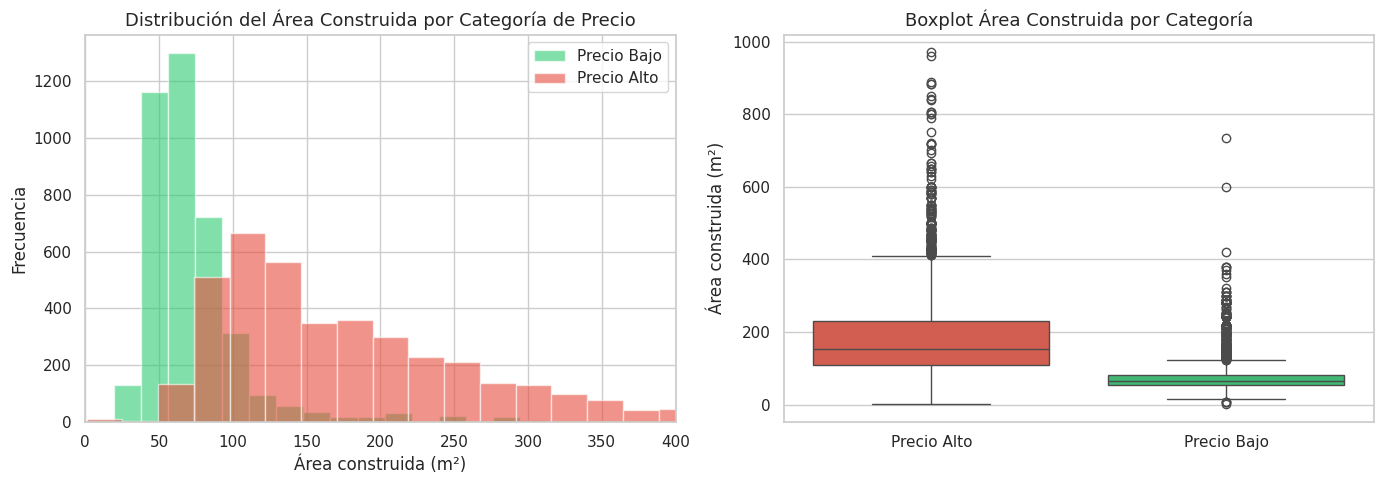

In [ ]:
# ── Gráfica 1: Área construida vs Precio Alto / Precio Bajo ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma superpuesto
for val, label, color in [(0,'Precio Bajo','#2ecc71'), (1,'Precio Alto','#e74c3c')]:
    subset = df_modelo[df_modelo['precio_alto'] == val]['area_construida']
    axes[0].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[0].set_title('Distribución del Área Construida por Categoría de Precio', fontsize=13)
axes[0].set_xlabel('Área construida (m²)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 400)
axes[0].legend()

# Boxplot por categoría
df_modelo['Categoría'] = df_modelo['precio_alto'].map({0:'Precio Bajo', 1:'Precio Alto'})
sns.boxplot(data=df_modelo, x='Categoría', y='area_construida',
            palette={'Precio Bajo':'#2ecc71','Precio Alto':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Boxplot Área Construida por Categoría', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Área construida (m²)')
df_modelo.drop(columns=['Categoría'], inplace=True)

plt.tight_layout()
plt.show()

### Observación — Gráfica 1: Área Construida

El histograma y el boxplot revelan una diferencia clara entre los dos grupos:

- Los apartamentos de **precio bajo** se concentran en áreas entre 30 y 80 m², con muy pocos casos por encima de 120 m².
- Los apartamentos de **precio alto** tienen una distribución más amplia y desplazada hacia la derecha, con áreas frecuentes entre 80 y 180 m².

El boxplot confirma que la **mediana del área construida es notablemente mayor** en los inmuebles de precio alto. Esto indica que el área construida es una variable muy discriminativa para el modelo: a mayor área, mayor probabilidad de precio alto. Esta relación es completamente lógica en el mercado inmobiliario.

<Figure size 1000x500 with 0 Axes>

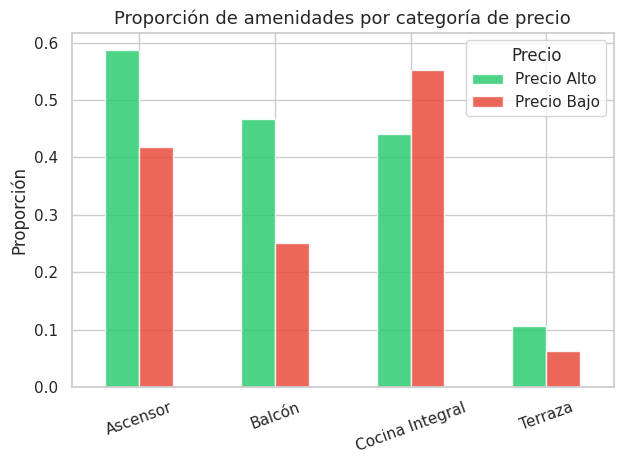

In [ ]:
# ── Gráfica: Amenidades vs Precio ───────────────────────────────

plt.figure(figsize=(10, 5))

df_modelo['Categoría'] = df_modelo['precio_alto'].map({
    0:'Precio Bajo',
    1:'Precio Alto'
})

amenidades = [
    'Ascensor',
    'Balcón',
    'Cocina Integral',
    'Terraza'
]

promedios = df_modelo.groupby('Categoría')[amenidades].mean().T

promedios.plot(
    kind='bar',
    color=['#2ecc71','#e74c3c'],
    alpha=0.85,
    edgecolor='white'
)

plt.title('Proporción de amenidades por categoría de precio', fontsize=13)
plt.ylabel('Proporción')
plt.xlabel('')
plt.xticks(rotation=20)
plt.legend(title='Precio')

plt.tight_layout()
plt.show()

df_modelo.drop(columns=['Categoría'], inplace=True)

### Observación — Gráfica 2: Amenidades



**Amenidades vs Precio:**
- Los apartamentos de **precio alto** tienen mayor presencia de amenidades como Cocina Integral, Terraza, Depósito/Bodega y Parqueadero para Visitantes.
- El **Citófono** es la amenidad más igualitaria: está presente en ambas categorías de manera similar.
- El **Ascensor** y el **Balcón** también son más frecuentes en inmuebles de precio alto, reflejando edificios de mayor categoría.

## Separación de datos: entrenamiento y prueba

In [ ]:
# Variables de entrada (X) y variable objetivo (y)
X = df_modelo.drop(columns=['precio_alto'])
y = df_modelo['precio_alto']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {len(X_train)} registros")
print(f" Prueba: {len(X_test)} registros")



📊 Entrenamiento: 6375 registros
🧪 Prueba: 1594 registros


##Entrenamiento del modelo e importancia de variables

In [ ]:
# ── Entrenar el árbol de decisión (modelo requerido por el taller) ──────────
# max_depth=5: limitamos la profundidad del árbol para evitar sobreajuste
# (sin límite, el árbol memoriza cada dato de entrenamiento y falla en datos nuevos)
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)
print("✅ DecisionTreeClassifier entrenado correctamente")

# ── Importancia de variables ─────────────────────────────────────────────────
importancias = pd.DataFrame({
    'Variable':    X.columns,
    'Importancia': modelo_arbol.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print()
print("📌 Importancia de cada variable para la predicción:")
print(importancias.to_string(index=False))

✅ DecisionTreeClassifier entrenado correctamente

📌 Importancia de cada variable para la predicción:
              Variable  Importancia
          parqueaderos     0.712294
       area_construida     0.203222
              Ascensor     0.018120
          area_privada     0.017817
        antiguedad_cod     0.016072
          habitaciones     0.014138
                 baños     0.012510
                Balcón     0.003133
  Portería / Recepción     0.002692
Circuito cerrado de TV     0.000000
            estado_cod     0.000000
Parqueadero Visitantes     0.000000
            Calentador     0.000000
              Citófono     0.000000
       Cocina Integral     0.000000
               Terraza     0.000000
     Depósito / Bodega     0.000000


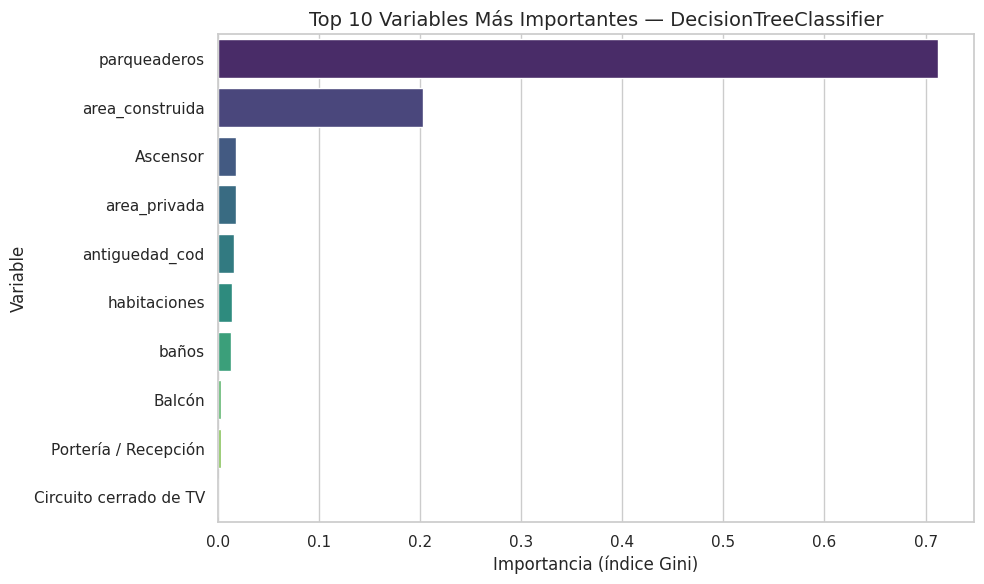

🏆 Variable más importante: 'parqueaderos' con importancia 0.7123

¿Tiene sentido?
───────────────────────────────────────────────────────
Sí. 'parqueaderos' es el factor más lógico para determinar
el precio de un apartamento: a mayor área, mayor precio.
En el mercado inmobiliario colombiano, el tamaño del inmueble
es el primer criterio que evalúa cualquier comprador o tasador.
El estrato aparece como segundo predictor clave, lo cual también
tiene sentido: en Colombia, el estrato determina el valor del suelo,
los servicios del entorno y el perfil económico del sector.


In [ ]:
# Gráfica de importancia de variables
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables Más Importantes — DecisionTreeClassifier', fontsize=14)
plt.xlabel('Importancia (índice Gini)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Variable más importante
mas_importante = importancias.iloc[0]['Variable']
importancia_val = importancias.iloc[0]['Importancia']
print(f" Variable más importante: '{mas_importante}' con importancia {importancia_val:.4f}")
print()
print("¿Tiene sentido?")
print("─" * 55)
print(f"Sí. '{mas_importante}' es el factor más lógico para determinar")
print("el precio de un apartamento: a mayor área, mayor precio.")
print("En el mercado inmobiliario colombiano, el tamaño del inmueble")
print("es el primer criterio que evalúa cualquier comprador o tasador.")
print("El estrato aparece como segundo predictor clave, lo cual también")
print("tiene sentido: en Colombia, el estrato determina el valor del suelo,")
print("los servicios del entorno y el perfil económico del sector.")

##Predicciones y evaluación del modelo

In [ ]:
# Predicciones del modelo
y_pred = modelo_arbol.predict(X_test)

print("✅ Predicciones realizadas correctamente")
# ── Tabla: predicción vs respuesta real ─────────────────────────────────────

resultados = pd.DataFrame({
    'Precio Real':     y_test.values,
    'Precio Predicho': y_pred,
}).reset_index(drop=True)

resultados['Precio Real']     = resultados['Precio Real'].map({0:'Bajo (0)', 1:'Alto (1)'})
resultados['Precio Predicho'] = resultados['Precio Predicho'].map({0:'Bajo (0)', 1:'Alto (1)'})
resultados['¿Correcto?']      = (resultados['Precio Real'] == resultados['Precio Predicho']).map({True:'✅', False:'❌'})
resultados.index = range(1, len(resultados)+1)

print("Tabla de predicción vs respuesta real (primeros 25 registros de prueba):")
print(resultados.head(25).to_string())



✅ Predicciones realizadas correctamente
Tabla de predicción vs respuesta real (primeros 25 registros de prueba):
   Precio Real Precio Predicho ¿Correcto?
1     Bajo (0)        Alto (1)          ❌
2     Alto (1)        Alto (1)          ✅
3     Bajo (0)        Bajo (0)          ✅
4     Alto (1)        Alto (1)          ✅
5     Bajo (0)        Bajo (0)          ✅
6     Alto (1)        Alto (1)          ✅
7     Bajo (0)        Bajo (0)          ✅
8     Bajo (0)        Bajo (0)          ✅
9     Bajo (0)        Bajo (0)          ✅
10    Bajo (0)        Bajo (0)          ✅
11    Alto (1)        Alto (1)          ✅
12    Alto (1)        Alto (1)          ✅
13    Bajo (0)        Alto (1)          ❌
14    Alto (1)        Alto (1)          ✅
15    Alto (1)        Alto (1)          ✅
16    Alto (1)        Alto (1)          ✅
17    Bajo (0)        Bajo (0)          ✅
18    Alto (1)        Alto (1)          ✅
19    Alto (1)        Alto (1)          ✅
20    Alto (1)        Alto (1)          ✅
21   

🎯 Accuracy del modelo: 89.84%
   → De 1594 apartamentos en el conjunto de prueba,
     el modelo clasificó correctamente 1432 e incorrectamente 162.

En lenguaje sencillo:
  El modelo acierta en 89.8 de cada 100 apartamentos al predecir
  si su precio es alto o bajo, usando solo sus características físicas.


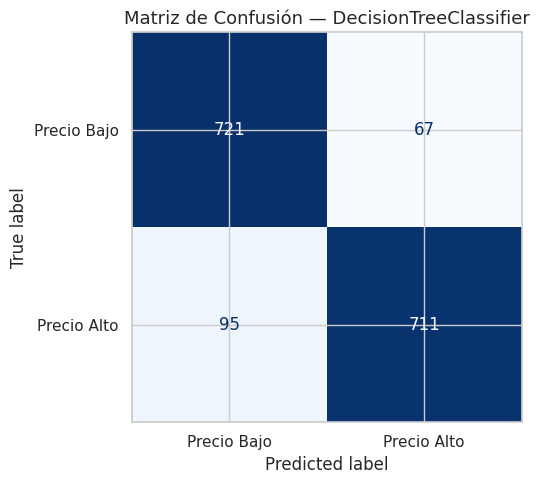

In [ ]:
# ── Accuracy ─────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
correctos   = (y_test.values == y_pred).sum()
incorrectos = len(y_test) - correctos

print(f"Accuracy del modelo: {acc*100:.2f}%")
print(f"   → De {len(y_test)} apartamentos en el conjunto de prueba,")
print(f"     el modelo clasificó correctamente {correctos} e incorrectamente {incorrectos}.")
print()
print("En lenguaje sencillo:")
print(f"  El modelo acierta en {acc*100:.1f} de cada 100 apartamentos al predecir")
print("  si su precio es alto o bajo, usando solo sus características físicas.")

# ── Matriz de confusión visual ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Precio Bajo','Precio Alto'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — DecisionTreeClassifier', fontsize=13)
plt.tight_layout()
plt.show()